In [1]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)
src_dir = os.path.join(root_dir, "src")

# Add src folder (parent of PyGhostID) to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import core as part of PyGhostID package
from PyGhostID import core as gid
print(gid.__file__)
import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection


pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting


w:\GitHub\GhostID\src\PyGhostID\core.py
w:\GitHub\GhostID\paper\utils_paper.py


Figure 4a - single ghost in ecological model from Bieg et al. 2024

<>:58: SyntaxWarning: invalid escape sequence '\d'
<>:60: SyntaxWarning: invalid escape sequence '\d'
<>:58: SyntaxWarning: invalid escape sequence '\d'
<>:60: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1907090065.py:58: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_range,y_cNC,'-b',label='$\dot{C} = 0$')
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1907090065.py:60: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_range,y_mNC,'--',color='deepskyblue',label='$\dot{M} = 0$')
w:\GitHub\GhostID\paper\models_paper.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  dM = z[1]*(a*z[0]*(Nt/(N0+Nt))-g/(z[1]+B)+y*B)
w:\GitHub\GhostID\paper\models_paper.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  dM = z[1]*(a*z[0]*(Nt/(N0+Nt))-g/(z[1]+B)+y*B)
w:\GitHub\GhostID\paper\models_paper.py:36: RuntimeWarning: divide by zero encountered in divide
  M = 1-C+a*C/y*(Nt/(N0+Nt))-g/(y*(1-C))


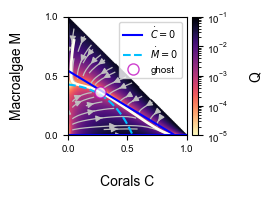

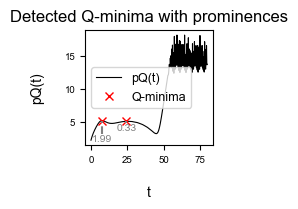

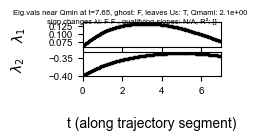

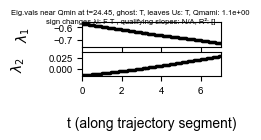

In [8]:

# set parameters
a = 2.0; y = 0.7; m = 0.15; g = 0.4; Nt = 0.53; N0 = 0.5; r = 1.8; c = 0.25
parameters_bieg =  [a,Nt,N0,g,y,r,c,m]

# simulate trajectory 
dt = 0.05
timesteps = np.linspace(0,80,int(80/dt))
sol = solve_ivp(mod.bieg_etal, (0, 80), [0.05,0.8],
                    t_eval=timesteps, args=(parameters_bieg,),method='RK45')

# run ghostID
Trj=sol.y.T
ghostSeq, ctrlPlots = gid.ghostID(mod.bieg_etal,parameters_bieg,dt,Trj,peak_kwargs={"prominence":0,"width":50},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

# plot phase space
xmin=0;xmax=1
ymin=0;ymax=1

Ng=160
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.bieg_etal,parameters_bieg,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.bieg_etal(t,z,parameters_bieg)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

mask = (Yg > 1 - Xg)   # region to exclude
U_masked = np.ma.masked_where(mask, U)
V_masked = np.ma.masked_where(mask, V)

ax.streamplot(
    Xg, Yg,
    U_masked, V_masked,
    density=0.7,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0],sol.y[1],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-5 # Define log scale range 
vmax = 0.1 # Avoid zero or negative values 
Q_masked = np.ma.masked_where(mask, Q)
im = ax.imshow(Q_masked.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# nullclines
y_cNC = mod.bieg_etal_cNC(x_range,parameters_bieg)
y_mNC = mod.bieg_etal_mNC(x_range,parameters_bieg)
ax.plot(x_range,y_cNC,'-b',label='$\dot{C} = 0$')
ax.plot(x_range,0*x_range,'-b')
ax.plot(x_range,y_mNC,'--',color='deepskyblue',label='$\dot{M} = 0$')
ax.plot(0*y_range,y_range,'--b')

# plot ghost
gx,gy = ghostSeq[0]["position"]
ax.plot(gx,gy,'ow',mec='m',markersize=8,alpha=0.75,label='ghost')

# add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

#labels, limits, legend
ax.set_xlabel('Corals C'); ax.set_ylabel('Macroalgae M')
ax.set_xlim(xmin,xmax); ax.set_xticks([0,0.5,1])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,0.5,1])
ax.legend(fontsize=7)
plt.savefig("Figure4a_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("Figure4a_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.2*inCm)
axes[0].set_xlim(0,7)
axes[1].set_xlim(0,7)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Figure4a_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2.2*inCm)
axes[0].set_xlim(0,7)
axes[1].set_xlim(0,7)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Figure4a_evsQ2.svg")
plt.show()

Figure 4b, Hastings et al. 2018, saddle crawl-by

<>:52: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
<>:52: SyntaxWarning: invalid escape sequence '\d'
<>:53: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1104710408.py:52: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_range,y_NNC,'-b',label='$\dot{N} = 0$')
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1104710408.py:53: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_PNC,y_range,'--',color='deepskyblue',label='$\dot{P} = 0$')


No ghosts for Hastings model in saddle crawl-by regime identified.


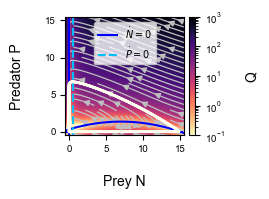

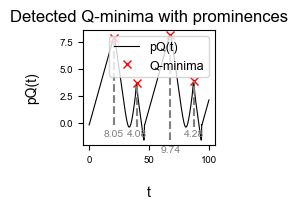

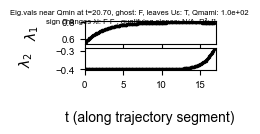

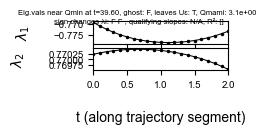

In [9]:

# set parameters
gamma=2.5;h=1;v=0.5;m=0.4;alpha=0.8;K=15;eps=1
parameters_hastings =  [gamma,h,v,m,alpha,K,eps]

# simulate trajectory 
dt = 0.1
timesteps = np.linspace(0,1e3,int(1e3/dt))
sol = solve_ivp(mod.Hastings_etal, (0, 1e3), [0.05,0.1],
                    t_eval=timesteps, args=(parameters_hastings,),method='RK45')

# run ghostID
Trj=sol.y[:,int(900/dt):].T
ghostSeq, ctrlPlots = gid.ghostID(mod.Hastings_etal,parameters_hastings,dt,Trj,0.1,peak_kwargs={"prominence":0,"width":10},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq)==0: print("No ghosts for Hastings model in saddle crawl-by regime identified.")

# plot phase space
xmin=-0.5;xmax=15.5
ymin=-0.5;ymax=15.5

Ng=160
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.Hastings_etal,parameters_hastings,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.Hastings_etal(t,z,parameters_hastings)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot Q-value
vmin = 1e-1 # Define log scale range 
vmax = 1000 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# # nullclines
y_NNC = mod.Hastings_NNC(x_range,parameters_hastings)
x_PNC = mod.Hastings_PNC(y_range,parameters_hastings)
ax.plot(x_range,y_NNC,'-b',label='$\dot{N} = 0$')
ax.plot(x_PNC,y_range,'--',color='deepskyblue',label='$\dot{P} = 0$')
ax.plot(0*y_range,y_range,'-b')
ax.plot(x_range,0*x_range,'--b') 

# plot trajectory
ax.plot(sol.y[0,int(900/dt):],sol.y[1,int(900/dt):],'-',color='ivory',lw=2)

# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel('Prey N'); ax.set_ylabel('Predator P')
ax.set_xlim(xmin,xmax); ax.set_xticks([0,5,10,15])
ax.set_ylim(ymin,ymax); ax.set_yticks([0,5,10,15])
ax.legend(fontsize=7)
plt.savefig("Figure4b_phaseSpace.svg")
plt.show()

#% Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("Figure4b_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2*inCm)
axes[0].set_xlim(0,17)
axes[1].set_xlim(0,17)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Figure4b_evsQ1.svg")
plt.show()

fig, axes = ctrlPlots[2]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,2*inCm)
axes[0].set_xlim(0,2)
axes[1].set_xlim(0,2)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Figure4b_evsQ2.svg")
plt.show()


Figure 4c, Fitz-Hugh Nagumo

<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:56: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1082528640.py:55: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(x_range,v(x_range),'-b',label='$\dot{u} = 0$')
C:\Users\dkoch\AppData\Local\Temp\ipykernel_14448\1082528640.py:56: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(u(y_range),y_range,'--',color='deepskyblue',label='$\dot{v} = 0$')


No ghosts for FHN model identified.


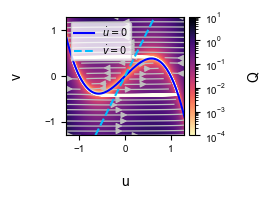

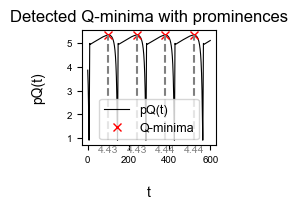

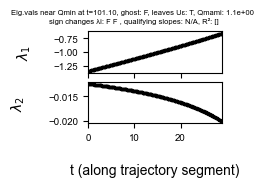

In [10]:

# set parameters
a=0;b=0.5;eps=0.01
parameters_FHN=  [a,b,eps]

# simulate trajectory 
dt = 0.1
timesteps = np.linspace(0,500,int(700/dt))
sol = solve_ivp(mod.FHN, (0, 500), [0.05,0.1],
                    t_eval=timesteps, args=(parameters_FHN,),method='RK45',rtol=1e-6,atol=1e-6)

# run ghostID
Trj=sol.y[:,int(100/dt):].T
ghostSeq, ctrlPlots = gid.ghostID(mod.FHN,parameters_FHN,dt,Trj,0.1,peak_kwargs={"prominence":0,"width":10},ctrlOutputs={"ctrl_qplot":True,"qplot_xscale":"linear","ctrl_evplot":True,"return_ctrl_figs":True}) #

if len(ghostSeq)==0: print("No ghosts for FHN model identified.")

# plot phase space
xmin=-1.3;xmax=1.3
ymin=-1.3;ymax=1.3

Ng=160
x_range=np.linspace(xmin,xmax,Ng)
y_range=np.linspace(ymin,ymax,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss

Q, coords = gid.qOnGrid(mod.FHN,parameters_FHN,coords=[x_range,y_range], jit=True)

plt.figure(figsize=(4.25*inCm,6*inCm))
ax = plt.gca()

def flow_model(t,z): 
        return mod.FHN(t,z,parameters_FHN)
U,V=fun.vector_field(flow_model,(Xg, Yg),dim='2D') 

ax.streamplot(
    Xg, Yg,
    U,V,
    density=0.8,
    color=[0.75, 0.75, 0.75, 1],
    arrowsize=0.9,
    linewidth=0.9)

# plot trajectory
ax.plot(sol.y[0,int(100/dt):],sol.y[1,int(100/dt):],'-',color='ivory',lw=2)

# plot Q-value
vmin = 1e-4 # Define log scale range 
vmax = 10 # Avoid zero or negative values 
im = ax.imshow(Q.T, extent=(x_range.min(), x_range.max(), y_range.min(), y_range.max()), aspect=1, origin='lower', cmap='magma_r', norm=LogNorm(vmin=vmin, vmax=vmax)) 

# # nullclines
v = lambda u: u - u**3 # u-Nullcline # u=x, v=y
u = lambda v: b*v-a # v-Nullcline
ax.plot(x_range,v(x_range),'-b',label='$\dot{u} = 0$')
ax.plot(u(y_range),y_range,'--',color='deepskyblue',label='$\dot{v} = 0$')

# # add colorbar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax,label="Q")

# #labels, limits, legend
ax.set_xlabel('u'); ax.set_ylabel('v')
ax.set_xlim(xmin,xmax); ax.set_xticks([-1,0,1])
ax.set_ylim(ymin,ymax); ax.set_yticks([-1,0,1])
ax.legend(fontsize=7)
plt.savefig("Figure5d_phaseSpace.svg")
plt.show()

# Plot control outputs from ghostID

# pQ timeseries and Q-minima
fig, ax = ctrlPlots[0]
fig.set_size_inches(4.5*inCm,5.5*inCm)
plt.figure(fig)
plt.savefig("Figure5d_pQ.svg")
plt.show()

# eigenvalues across trajectories
fig, axes = ctrlPlots[1]
suptxt = fig._suptitle.get_text()
fig.suptitle(suptxt,fontsize=5.5)
fig.set_size_inches(5*inCm,3.75*inCm)
axes[0].set_xlim(0,29)
axes[1].set_xlim(0,29)
axes[0].set_ylabel('$\\lambda_1$')
axes[1].set_ylabel('$\\lambda_2$')
axes[1].set_xlabel('t (along trajectory segment)')
plt.figure(fig)
plt.savefig("Figure5d_evsQ1.svg")
plt.show()
